In [2]:
experiment = "vggnet16_benchmark2022_segmented_all"

import pandas as pd
CSV_PATH = f"../results/{experiment}/combined_results.csv"
df = pd.read_csv(CSV_PATH)

In [3]:
import pandas as pd
GROUP_COL = "image"             # or "instance_id"

# ---- 1) Load + normalize
df = pd.read_csv(CSV_PATH)

for c in ["tag", GROUP_COL]:
    df[c] = df[c].astype(str).str.strip()

# (optional) make tag comparisons case-insensitive
df["tag_norm"] = df["tag"].str.lower()

# ---- 2) Define the exact expected 12 tags per label
# Edit this list to match your REAL tag strings exactly.
EXPECTED_TAGS = [
    # 4 globals (example: 2 eps * 2 k, etc.)  <-- replace with your real 12
    "n01440764_tench_global",
    "n01440764_tench_sego_fixmask",
    "n01440764_tench_sego_fixnonmask",
    # ... add the remaining 9 ...
]

# If your tags include the label prefix (like n01440764_tench_*), the above won't work globally.
# Usually you want expected "suffixes" instead, e.g.:
#   ["global", "seg0_fixmask", "seg0_fixnonmask", ...]
# Then check by pattern.
#
# If you truly mean "12 rows per label" regardless of exact names,
# you can skip EXPECTED_TAGS entirely and just count rows (see below).

# ---- 3) Basic check: exactly 12 rows per label
counts = df.groupby(GROUP_COL).size().rename("n_rows")
bad_count = counts[counts != 12].reset_index()

print("Labels with row-count != 12:")
print(bad_count if len(bad_count) else "None ✅")

# ---- 4) Stronger check: per label, check missing/extra tags vs expected
# If you DON'T want this, you can delete this whole section.
expected_set = set([t.strip().lower() for t in EXPECTED_TAGS])

def tag_set_for_group(g: pd.DataFrame):
    return set(g["tag_norm"].tolist())

rows = []
for label, g in df.groupby(GROUP_COL):
    got = tag_set_for_group(g)
    missing = sorted(list(expected_set - got))
    extra = sorted(list(got - expected_set))
    rows.append({
        GROUP_COL: label,
        "n_rows": len(g),
        "missing_tags": missing,
        "extra_tags": extra,
        "complete_12_expected": (len(g) == 12) and (len(missing) == 0) and (len(extra) == 0),
    })

coverage = pd.DataFrame(rows).sort_values(["complete_12_expected", "n_rows", GROUP_COL])

print("\nCoverage report (first 30 rows):")
print(coverage.head(30))

print("\nIncomplete labels:")
print(coverage[coverage["complete_12_expected"] == False][[GROUP_COL, "n_rows", "missing_tags", "extra_tags"]])

Labels with row-count != 12:
                 image  n_rows
0  n03250847_drumstick      14

Coverage report (first 30 rows):
                                 image  n_rows  \
0                      n01440764_tench      12   
1                   n01443537_goldfish      12   
2          n01484850_great_white_shark      12   
3                n01491361_tiger_shark      12   
4               n01496331_electric_ray      12   
5                       n01514668_cock      12   
6                        n01514859_hen      12   
7                    n01518878_ostrich      12   
8                  n01530575_brambling      12   
9                  n01531178_goldfinch      12   
10               n01532829_house_finch      12   
11                     n01534433_junco      12   
12            n01537544_indigo_bunting      12   
13                     n01558993_robin      12   
14                    n01560419_bulbul      12   
15                       n01580077_jay      12   
16                    n01

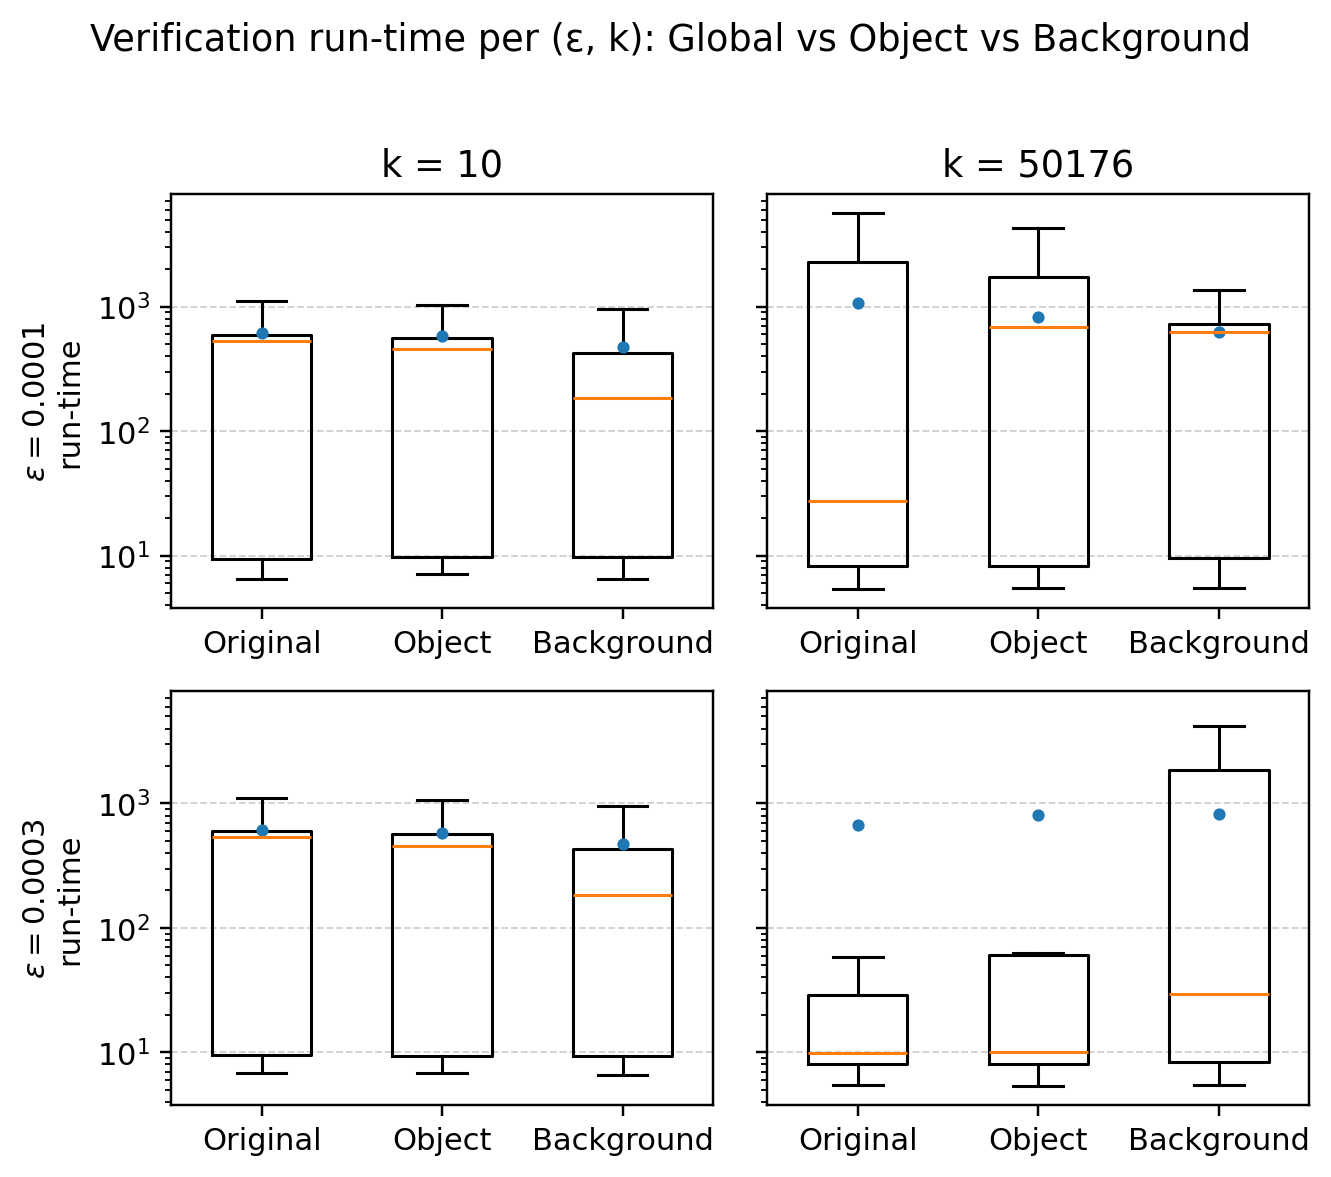

In [4]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Helpers
# ---------------------------
TIME_COL = "all_time" if "all_time" in df.columns else "bab_time"

def filter_by_tag_contains(frame: pd.DataFrame, include_any=(), include_all=(), exclude_any=()):
    tag = frame["tag"].astype(str)
    keep = pd.Series(True, index=frame.index)

    if include_any:
        keep_any = pd.Series(False, index=frame.index)
        for s in include_any:
            keep_any |= tag.str.contains(s, case=False, na=False)
        keep &= keep_any

    for s in include_all:
        keep &= tag.str.contains(s, case=False, na=False)

    if exclude_any:
        for s in exclude_any:
            keep &= ~tag.str.contains(s, case=False, na=False)

    return frame[keep].copy()

def sanitize_numeric(frame: pd.DataFrame):
    out = frame.copy()
    out["eps"] = pd.to_numeric(out["eps"], errors="coerce")
    out["k"] = pd.to_numeric(out["k"], errors="coerce")
    out[TIME_COL] = pd.to_numeric(out[TIME_COL], errors="coerce")
    out = out.dropna(subset=["eps", "k", TIME_COL]).copy()
    out = out[out[TIME_COL] > 0].copy()
    return out

def grouped_boxplot_one_panel(ax, triplet_data, labels, show_means=True):
    """
    triplet_data: [global_times, object_times, background_times]
    """
    ax.boxplot(triplet_data, tick_labels=labels, showfliers=False, widths=0.55)

    if show_means:
        means = [np.mean(v) if len(v) else np.nan for v in triplet_data]
        ax.plot([1, 2, 3], means, marker="o", linestyle="none", markersize=3)

    ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

# ---------------------------
# Build subsets (KEEPING YOUR STYLE, but FIXED SEMANTICS)
# ---------------------------

# Global
if "is_global" in df.columns:
    df_global = df[df["is_global"] == True].copy()
else:
    df_global = filter_by_tag_contains(df, include_any=("global",))

# Object verification = fix_nonmask (background fixed)
# (your previous "seg + mask excluding non-mask" was unreliable)
df_object = filter_by_tag_contains(df, include_any=("fixnonmask", "fix_nonmask", "fix_non_mask"))

# Background verification = fix_mask (object fixed)
df_background = filter_by_tag_contains(df, include_any=("fixmask", "fix_mask"))

# Sanitize
df_global = sanitize_numeric(df_global)
df_object = sanitize_numeric(df_object)
df_background = sanitize_numeric(df_background)

# ---------------------------
# Decide which eps and k to plot (12 panels)
# ---------------------------
# Use common eps across all three so panels are comparable
eps_vals = sorted(set(df_global["eps"]) & set(df_object["eps"]) & set(df_background["eps"]))

# Use common k across all three
k_vals = sorted(set(df_global["k"]) & set(df_object["k"]) & set(df_background["k"]))

# If you want EXACTLY 4 eps × 3 k = 12 panels, trim here if needed:
# eps_vals = eps_vals[:4]
# k_vals = k_vals[:3]

# ---------------------------
# Plot grid: rows=eps, cols=k  (=> 4x3 = 12)
# ---------------------------
rows = len(eps_vals)
cols = len(k_vals)

fig, axes = plt.subplots(rows, cols, figsize=(cols*3.1, rows*2.6), dpi=220, sharey=True)
axes = np.array(axes).reshape(rows, cols)

xlabels = [
    "Original",
    "Object",
    "Background",
]

for i, eps in enumerate(eps_vals):
    for j, k in enumerate(k_vals):
        ax = axes[i, j]

        g = df_global[(df_global["eps"] == eps) & (df_global["k"] == k)][TIME_COL].values
        o = df_object[(df_object["eps"] == eps) & (df_object["k"] == k)][TIME_COL].values
        b = df_background[(df_background["eps"] == eps) & (df_background["k"] == k)][TIME_COL].values

        grouped_boxplot_one_panel(ax, [g, o, b], xlabels, show_means=True)

        # Titles: keep compact
        if i == 0:
            ax.set_title(f"k = {int(k)}")
        if j == 0:
            ax.set_ylabel(rf"$\epsilon={eps:g}$" + "\nrun-time")

        ax.set_yscale("log")

# overall title
fig.suptitle("Verification run-time per (ε, k): Global vs Object vs Background", y=1.02)

plt.tight_layout()
plt.show()

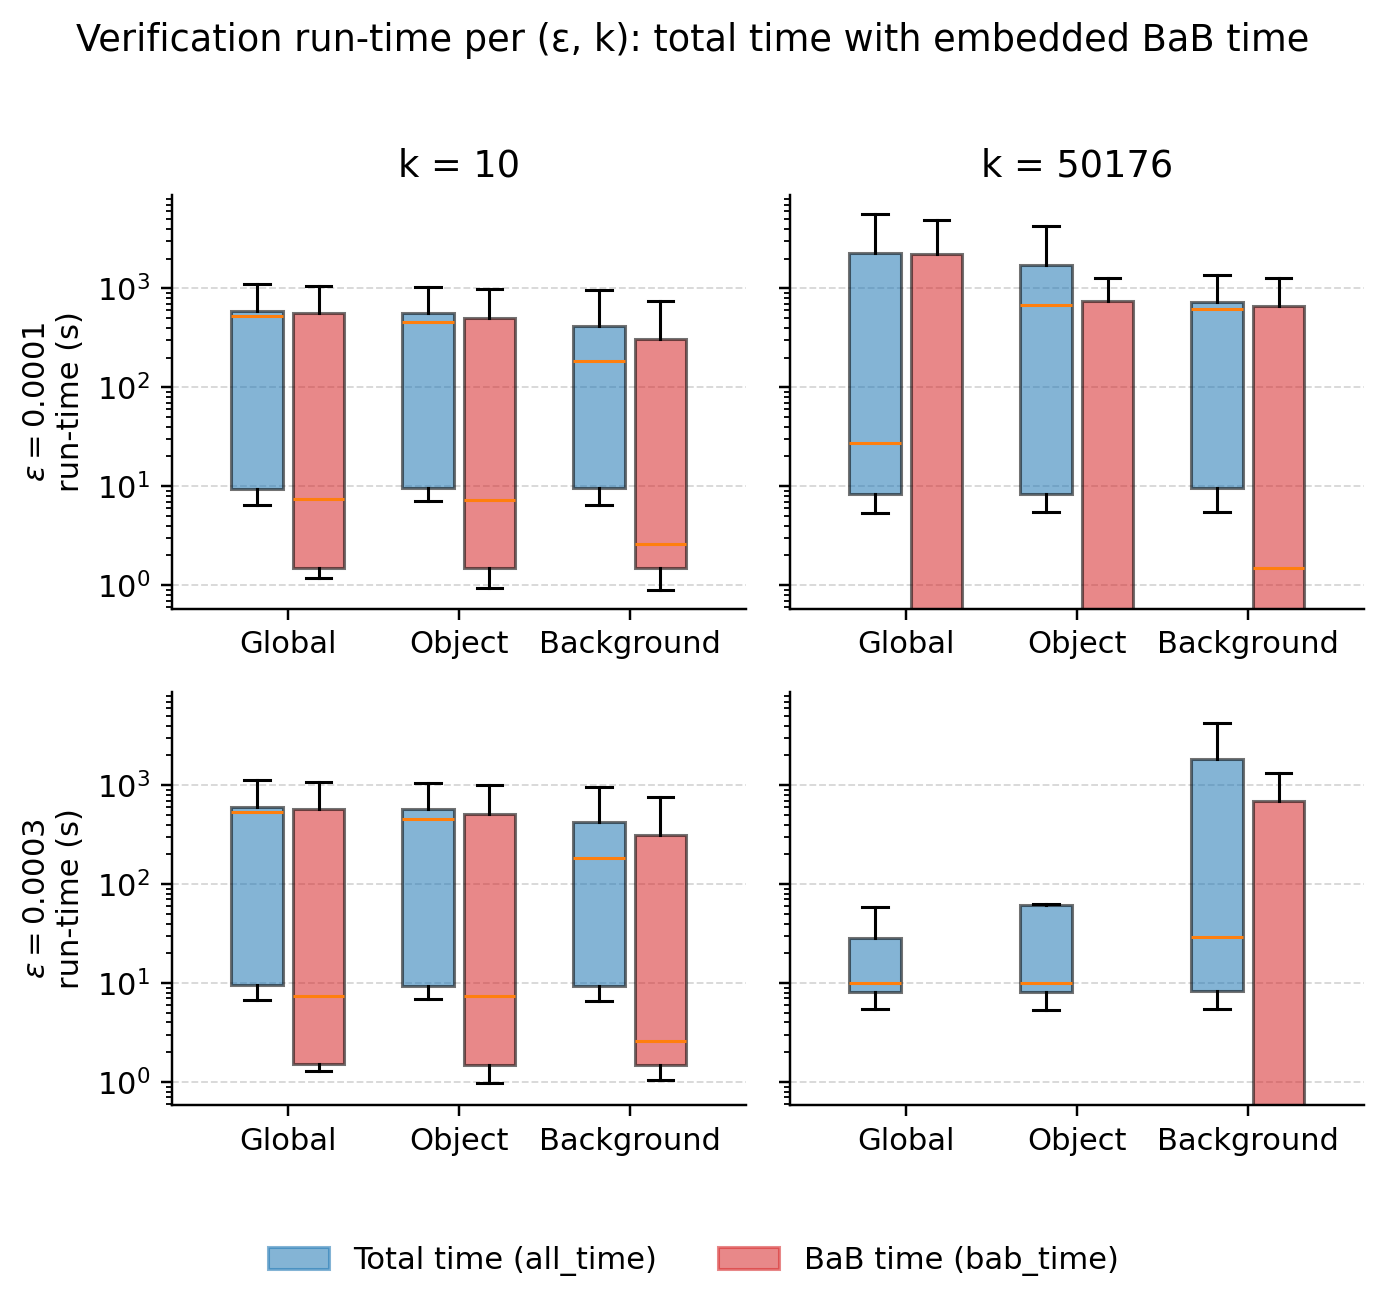

In [5]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---------------------------
# Helpers (keep your filtering logic)
# ---------------------------
ALL_COL = "all_time"
BAB_COL = "bab_time"

def filter_by_tag_contains(frame: pd.DataFrame, include_any=(), include_all=(), exclude_any=()):
    tag = frame["tag"].astype(str)
    keep = pd.Series(True, index=frame.index)

    if include_any:
        keep_any = pd.Series(False, index=frame.index)
        for s in include_any:
            keep_any |= tag.str.contains(s, case=False, na=False)
        keep &= keep_any

    for s in include_all:
        keep &= tag.str.contains(s, case=False, na=False)

    if exclude_any:
        for s in exclude_any:
            keep &= ~tag.str.contains(s, case=False, na=False)

    return frame[keep].copy()

def sanitize_numeric(frame: pd.DataFrame):
    out = frame.copy()
    out["eps"] = pd.to_numeric(out["eps"], errors="coerce")
    out["k"] = pd.to_numeric(out["k"], errors="coerce")
    out[ALL_COL] = pd.to_numeric(out[ALL_COL], errors="coerce")
    out[BAB_COL] = pd.to_numeric(out[BAB_COL], errors="coerce")

    out = out.dropna(subset=["eps", "k", ALL_COL]).copy()
    out = out[out[ALL_COL] > 0].copy()

    # If bab_time missing -> 0 (means never entered BaB)
    if BAB_COL in out.columns:
        out[BAB_COL] = out[BAB_COL].fillna(0)
        out.loc[out[BAB_COL] < 0, BAB_COL] = 0

    return out

def paired_boxplot_one_panel(ax, data_pairs, base_labels):
    """
    data_pairs: list of tuples [(total_times, bab_times), ...] for each base label.
    base_labels: ["Global", "Object", "Background"]

    Draws 2 boxes per label: Total + BaB, side-by-side.
    """
    # positions: for x=1,2,3 we place total at x-0.18 and bab at x+0.18
    centers = np.arange(1, len(base_labels) + 1)
    pos_total = centers - 0.18
    pos_bab   = centers + 0.18

    total_data = [p[0] for p in data_pairs]
    bab_data   = [p[1] for p in data_pairs]

    # Total boxes
    bp1 = ax.boxplot(
        total_data, positions=pos_total, widths=0.30,
        showfliers=False, patch_artist=True
    )
    # BaB boxes
    bp2 = ax.boxplot(
        bab_data, positions=pos_bab, widths=0.30,
        showfliers=False, patch_artist=True
    )

    # Styling (paper-ish)
    for b in bp1["boxes"]:
        b.set_facecolor("#1f77b4")  # Total
        b.set_alpha(0.55)
        b.set_linewidth(1.0)
    for b in bp2["boxes"]:
        b.set_facecolor("#d62728")  # BaB
        b.set_alpha(0.55)
        b.set_linewidth(1.0)

    for key in ["whiskers", "caps", "medians"]:
        for line in bp1[key]:
            line.set_linewidth(1.0)
        for line in bp2[key]:
            line.set_linewidth(1.0)

    ax.set_xticks(centers)
    ax.set_xticklabels(base_labels, rotation=0)
    ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.5)

# ---------------------------
# Build subsets (your semantics)
# ---------------------------
# Global
if "is_global" in df.columns:
    df_global = df[df["is_global"] == True].copy()
else:
    df_global = filter_by_tag_contains(df, include_any=("global",))

# Object verification = fix_nonmask (background fixed)
df_object = filter_by_tag_contains(df, include_any=("fixnonmask", "fix_nonmask", "fix_non_mask"))

# Background verification = fix_mask (object fixed)
df_background = filter_by_tag_contains(df, include_any=("fixmask", "fix_mask"))

# Sanitize
df_global = sanitize_numeric(df_global)
df_object = sanitize_numeric(df_object)
df_background = sanitize_numeric(df_background)
# ---------------------------
# Plot grid: ACTUAL TIME (seconds), NOT normalized
# ---------------------------
rows = len(eps_vals)
cols = len(k_vals)

fig, axes = plt.subplots(rows, cols, figsize=(cols*3.2, rows*2.6), dpi=220, sharey=True)
axes = np.array(axes).reshape(rows, cols)

base_labels = ["Global", "Object", "Background"]

for i, eps in enumerate(eps_vals):
    for j, k in enumerate(k_vals):
        ax = axes[i, j]

        g_all = df_global[(df_global["eps"] == eps) & (df_global["k"] == k)][ALL_COL].values
        g_bab = df_global[(df_global["eps"] == eps) & (df_global["k"] == k)][BAB_COL].values

        o_all = df_object[(df_object["eps"] == eps) & (df_object["k"] == k)][ALL_COL].values
        o_bab = df_object[(df_object["eps"] == eps) & (df_object["k"] == k)][BAB_COL].values

        b_all = df_background[(df_background["eps"] == eps) & (df_background["k"] == k)][ALL_COL].values
        b_bab = df_background[(df_background["eps"] == eps) & (df_background["k"] == k)][BAB_COL].values

        paired_boxplot_one_panel(
            ax,
            data_pairs=[(g_all, g_bab), (o_all, o_bab), (b_all, b_bab)],
            base_labels=base_labels
        )

        # Titles / labels
        if i == 0:
            ax.set_title(f"k = {int(k)}")
        if j == 0:
            ax.set_ylabel(rf"$\epsilon={eps:g}$" + "\nrun-time (s)")

        # Log-scale is IMPORTANT for real times
        ax.set_yscale("log")

        # Paper look
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

# Overall title
fig.suptitle(
    "Verification run-time per (ε, k): total time with embedded BaB time",
    y=1.02
)

# Legend below
import matplotlib.patches as mpatches
total_patch = mpatches.Patch(color="#1f77b4", alpha=0.55, label="Total time (all_time)")
bab_patch   = mpatches.Patch(color="#d62728", alpha=0.55, label="BaB time (bab_time)")

fig.legend(
    handles=[total_patch, bab_patch],
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.1)
)

fig.subplots_adjust(bottom=0.14)
plt.tight_layout()
plt.show()

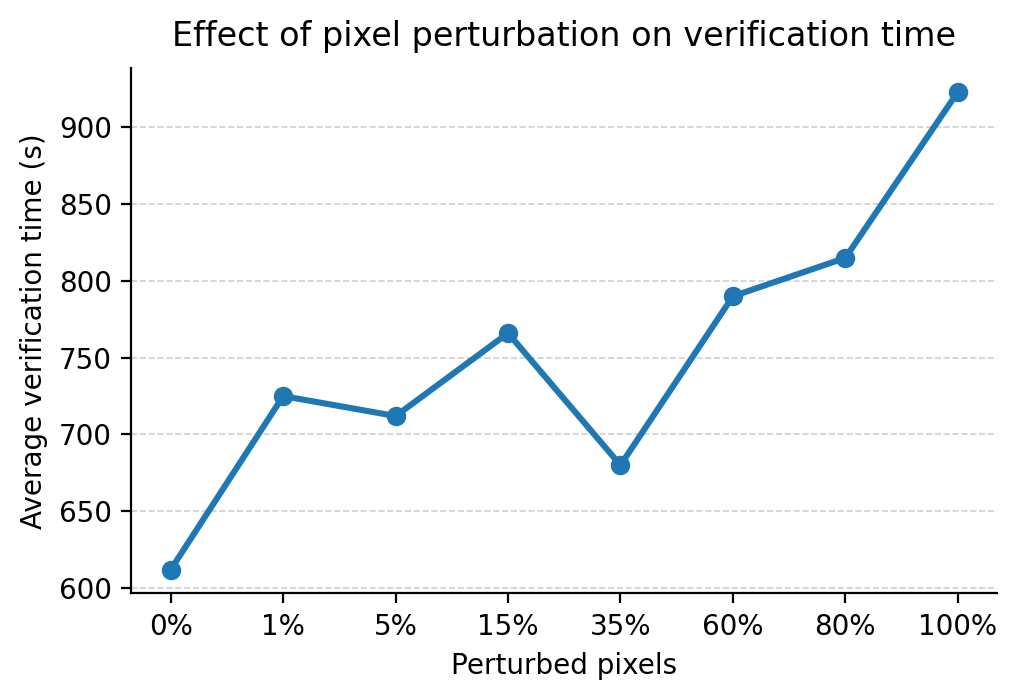

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# ---- your aggregated data (example) ----
pixel_vals = np.array([0, 1, 5, 15, 35, 60, 80, 100])
avg_time = np.array([612, 725, 712, 766, 680, 790, 815, 923])

# ---- categorical x positions (equal spacing) ----
x_pos = np.arange(len(pixel_vals))

# ---- plot ----
plt.figure(figsize=(5.2, 3.6), dpi=200)

plt.plot(
    x_pos,
    avg_time,
    marker="o",
    linewidth=2.2,
    markersize=6,
)

# ---- axis styling ----
plt.xticks(x_pos, [f"{p}%" for p in pixel_vals])
plt.xlabel("Perturbed pixels")
plt.ylabel("Average verification time (s)")

plt.title("Effect of pixel perturbation on verification time", pad=8)

# subtle grid (y only)
plt.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

# remove top/right spines (paper style)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

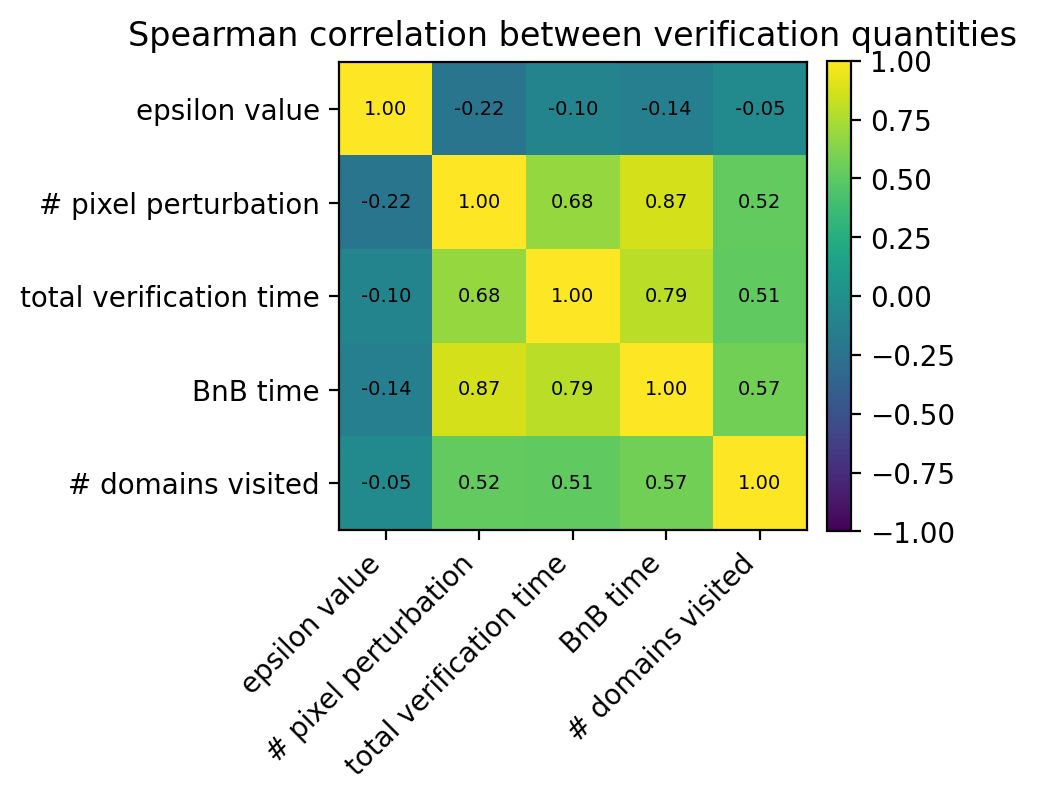

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------
# Select numeric columns
# ---------------------------------------
candidate_cols = [
    "eps",
    "percent_changed",
    "all_time",
    "bab_time",
    "domains_visited",
]

num_cols = [c for c in candidate_cols if c in df.columns]

# Convert to numeric safely
d = df[num_cols].apply(pd.to_numeric, errors="coerce")
d = d.dropna(how="any")

# ---------------------------------------
# Compute correlation (Spearman)
# ---------------------------------------
corr = d.corr(method="spearman")

# ---------------------------------------
# Pretty labels (DISPLAY ONLY)
# ---------------------------------------
LABEL_MAP = {
    "eps": "epsilon value",
    "percent_changed": "# pixel perturbation",
    "all_time": "total verification time",
    "bab_time": "BnB time",
    "domains_visited": "# domains visited",
}

corr = corr.rename(index=LABEL_MAP, columns=LABEL_MAP)

# ---------------------------------------
# Plot correlation heatmap
# ---------------------------------------
fig, ax = plt.subplots(figsize=(4.8, 4.2), dpi=200)

im = ax.imshow(corr, vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

# Annotate correlation values
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        val = corr.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7)

# title WITHOUT "percentage change only"
ax.set_title("Spearman correlation between verification quantities")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Verification cost correlates with perturbation size and search effort, not with ε.

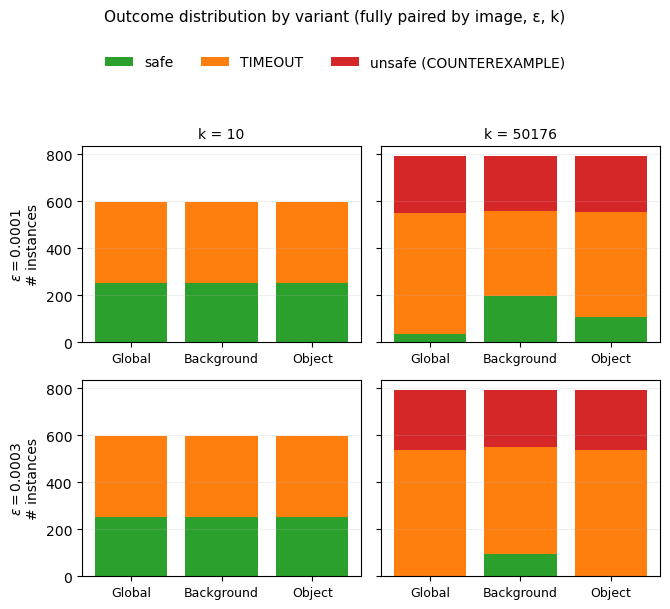

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
PAIR_COLS = ["image", "eps", "k"]

VARIANTS = ["Global", "Background", "Object"]
XTICK_LABELS = ["Global", "Background", "Object"]

# RESULT LABEL NORMALIZATION
RESULT_RENAME = {
    "unsat False": "safe",
    "timeout False": "TIMEOUT",
    "sat True": "unsafe (COUNTEREXAMPLE)",
}

RESULT_COLORS = {
    "unsafe (COUNTEREXAMPLE)": "#d62728",  # red
    "safe": "#2ca02c",                     # green
    "TIMEOUT": "#ff7f0e",                  # orange
}

RESULT_ORDER = ["safe", "TIMEOUT", "unsafe (COUNTEREXAMPLE)"]

# -----------------------------
# LOAD / CLEAN
# -----------------------------
df = df.copy()
df["eps"] = pd.to_numeric(df["eps"], errors="coerce")
df["k"]   = pd.to_numeric(df["k"], errors="coerce")
df["result"] = df["result"].astype(str)

# -----------------------------
# VARIANT CLASSIFIER (correct semantics)
# FixMask    -> Background
# FixNonMask -> Object
# -----------------------------
def classify_variant(row):
    pat = str(row.get("pattern", "")).lower()
    tag = str(row.get("tag", "")).lower()
    vnn = str(row.get("vnnlib", "")).lower()
    is_global = bool(row.get("is_global", False))

    if is_global or pat == "global" or "_global" in tag or "_global" in vnn:
        return "Global"

    s = " ".join([pat, tag, vnn])

    # prioritize fix_* keys
    if any(k in s for k in ["fix_mask", "fix-mask", "fixmask"]):
        return "Background"
    if any(k in s for k in ["fix_nonmask", "fix-nonmask", "fixnonmask", "fix_non_mask"]):
        return "Object"

    # fallback keys
    if any(k in s for k in ["background", "bg", "nonmask", "non-mask"]):
        return "Background"
    # NOTE: plain "mask" can collide with "nonmask"; keep it last
    if any(k in s for k in [" object", " obj", "foreground"]):
        return "Object"

    return None

df["variant"] = df.apply(classify_variant, axis=1)
df = df[df["variant"].isin(VARIANTS)].copy()

# Keep only seg0 for non-global
if "segment_index" in df.columns:
    df = df[(df["variant"] == "Global") | (df["segment_index"] == 0)].copy()

# Clean results
df = df[df["result"].isin(RESULT_RENAME)].copy()
df["result_clean"] = df["result"].map(RESULT_RENAME)

# -----------------------------
# PAIRED WIDE TABLE (fully paired)
# -----------------------------
res_all3 = df.pivot_table(
    index=PAIR_COLS,
    columns="variant",
    values="result_clean",
    aggfunc="first"
).reset_index()

res_all3 = res_all3.dropna(subset=VARIANTS).copy()

# -----------------------------
# MANY PLOTS: grid per (eps, k)
# rows = eps, cols = k
# -----------------------------
eps_values = sorted(res_all3["eps"].dropna().unique())
k_values = sorted(res_all3["k"].dropna().unique())

# If you want exactly 12 panels, set these explicitly:
# eps_values = [0.0001, 0.0002, 0.0003, 0.0004]
# k_values = [2, 784, 50176]

rows = len(eps_values)
cols = len(k_values)

fig, axes = plt.subplots(
    rows, cols,
    figsize=(cols * 3.4, rows * 2.8),
    squeeze=False,
    sharey=True
)

x = np.arange(len(VARIANTS))

for i, eps in enumerate(eps_values):
    for j, k in enumerate(k_values):
        ax = axes[i][j]
        sub = res_all3[(res_all3["eps"] == eps) & (res_all3["k"] == k)]

        if sub.empty:
            ax.axis("off")
            continue

        bottom = np.zeros(len(VARIANTS), dtype=float)

        for lab in RESULT_ORDER:
            vals = np.array([(sub[v] == lab).sum() for v in VARIANTS], dtype=float)
            ax.bar(
                x, vals,
                bottom=bottom,
                color=RESULT_COLORS[lab],
                label=lab if (i == 0 and j == 0) else None
            )
            bottom += vals

        ax.set_xticks(x)
        ax.set_xticklabels(XTICK_LABELS, fontsize=9)
        ax.grid(True, axis="y", alpha=0.2)

        # clean titles (no n=..., no images=...)
        if i == 0:
            ax.set_title(f"k = {int(k)}", fontsize=10)
        if j == 0:
            ax.set_ylabel(rf"$\epsilon = {eps:g}$" + "\n# instances", fontsize=10)

# Legend once
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

fig.suptitle(
    "Outcome distribution by variant (fully paired by image, ε, k)",
    y=1.08,
    fontsize=11
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [8]:
# Long format: one row per (image, eps, k, variant)
long = res_all3.melt(
    id_vars=PAIR_COLS,
    value_vars=VARIANTS,
    var_name="variant",
    value_name="result"
)

# Count + percentage
pct_table = (
    long
    .groupby(["eps", "k", "variant", "result"])
    .size()
    .reset_index(name="count")
)

pct_table["percent"] = (
    pct_table
    .groupby(["eps", "k", "variant"])["count"]
    .transform(lambda x: 100 * x / x.sum())
)

pct_table = pct_table.sort_values(["eps", "k", "variant", "result"])
print(pct_table)

       eps      k     variant                   result  count    percent
0   0.0001     10  Background                  TIMEOUT    343  57.453936
1   0.0001     10  Background                     safe    254  42.546064
2   0.0001     10      Global                  TIMEOUT    342  57.286432
3   0.0001     10      Global                     safe    255  42.713568
4   0.0001     10      Object                  TIMEOUT    343  57.453936
5   0.0001     10      Object                     safe    254  42.546064
6   0.0001  50176  Background                  TIMEOUT    361  45.408805
7   0.0001  50176  Background                     safe    197  24.779874
8   0.0001  50176  Background  unsafe (COUNTEREXAMPLE)    237  29.811321
9   0.0001  50176      Global                  TIMEOUT    519  65.283019
10  0.0001  50176      Global                     safe     34   4.276730
11  0.0001  50176      Global  unsafe (COUNTEREXAMPLE)    242  30.440252
12  0.0001  50176      Object                  TIME

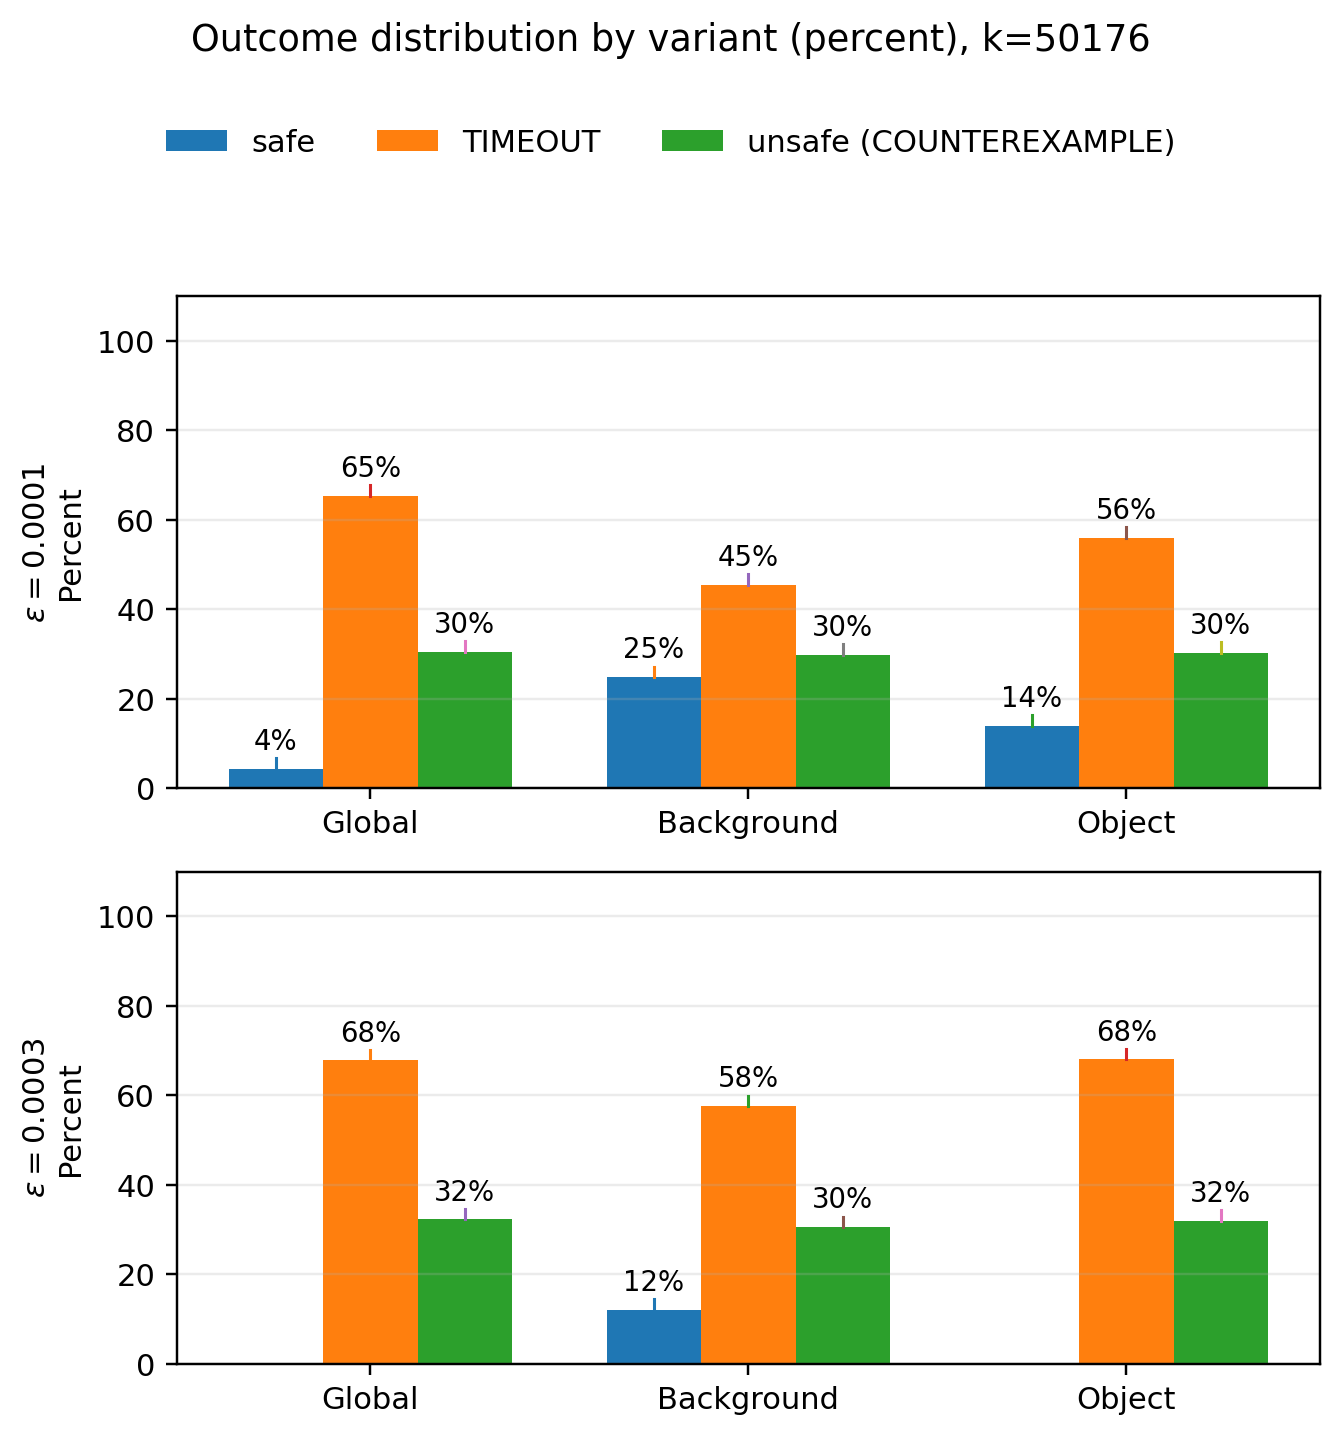

In [9]:
import matplotlib.pyplot as plt
import numpy as np

RESULT_ORDER  = ["safe", "TIMEOUT", "unsafe (COUNTEREXAMPLE)"]
VARIANT_ORDER = ["Global", "Background", "Object"]
K_TARGET = 50176

# Filter to k=50176
pt = pct_table[pct_table["k"] == K_TARGET].copy()
eps_values = sorted(pt["eps"].dropna().unique())

# One row per epsilon (you can change to 1xN if you prefer)
fig, axes = plt.subplots(
    len(eps_values), 1,
    figsize=(6.2, len(eps_values) * 3.0),
    sharey=True,
    squeeze=False,
    dpi=220
)
axes = axes[:, 0]

x = np.arange(len(VARIANT_ORDER))
bar_width = 0.25
label_pad = 3.0  # vertical spacing for label above bar

for i, eps in enumerate(eps_values):
    ax = axes[i]
    sub = pt[pt["eps"] == eps].copy()

    if sub.empty:
        ax.axis("off")
        continue

    # Plot grouped bars: three bars per variant (safe/timeout/unsafe)
    for r_idx, res in enumerate(RESULT_ORDER):
        vals = []
        for v in VARIANT_ORDER:
            row = sub[(sub["variant"] == v) & (sub["result"] == res)]
            vals.append(float(row["percent"].iloc[0]) if not row.empty else 0.0)
        vals = np.array(vals, dtype=float)

        xpos = x + (r_idx - 1) * bar_width
        bars = ax.bar(
            xpos, vals,
            width=bar_width,
            label=res if i == 0 else None
        )

        # Annotate EACH bar with a small connector line + percent text
        for b, v_pct in zip(bars, vals):
            if v_pct <= 0:
                continue
            xc = b.get_x() + b.get_width() / 2
            y  = b.get_height()

            # connector line
            ax.plot([xc, xc], [y, y + (label_pad * 0.8)], linewidth=1)

            # text
            ax.text(
                xc, y + label_pad,
                f"{v_pct:.0f}%",
                ha="center", va="bottom",
                fontsize=9
            )

    ax.set_xticks(x)
    ax.set_xticklabels(VARIANT_ORDER, fontsize=10)
    ax.set_ylim(0, 110)
    ax.grid(True, axis="y", alpha=0.25)
    ax.set_ylabel(rf"$\epsilon = {eps:g}$" + "\nPercent", fontsize=10)

# Legend once (top)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.02))

fig.suptitle(f"Outcome distribution by variant (percent), k={K_TARGET}", y=1.08, fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

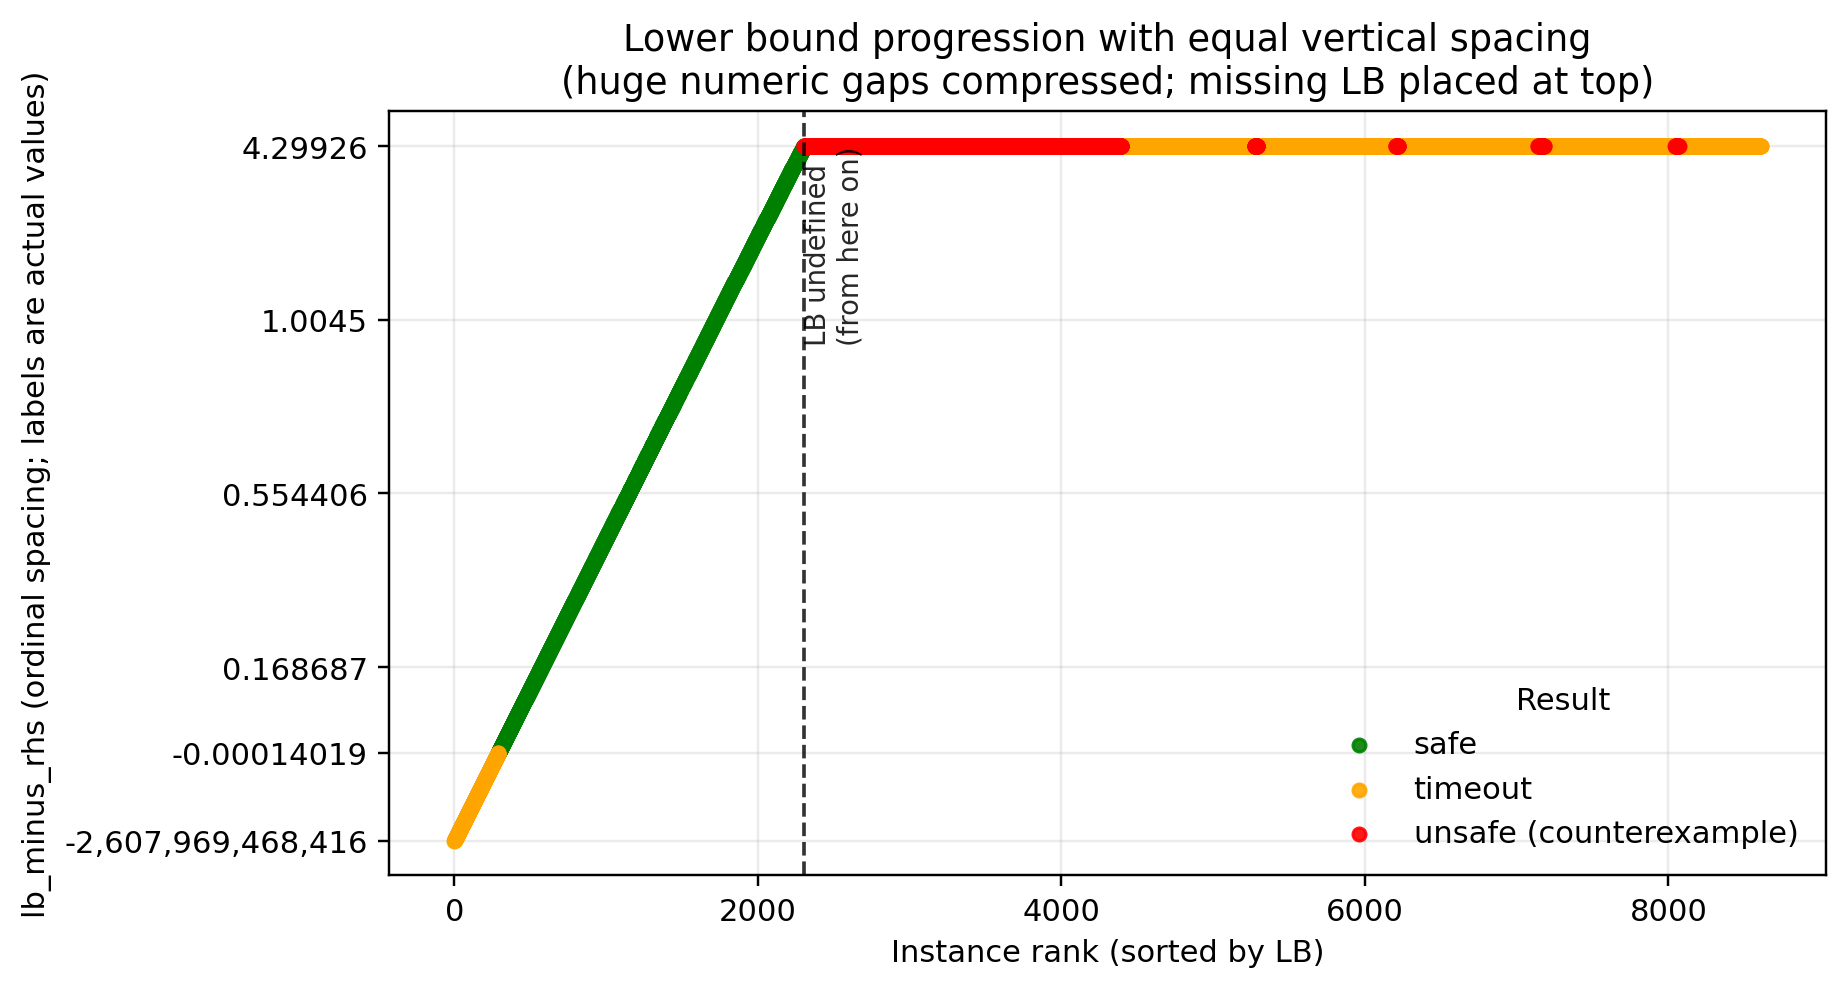

Unique finite LB values: 2289
Missing LB count: 6303


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

LB_COL = "lb_minus_rhs"
RESULT_COL = "result"

COLOR = {
    "timeout": "orange",
    "unsat": "green",
    "sat": "red",
    "other": "gray",
}

LEGEND_LABEL = {
    "unsat": "safe",
    "sat": "unsafe (counterexample)",
    "timeout": "timeout",
    "other": "other",
}

def canon_result(x):
    s = str(x).strip().lower()
    if "timeout" in s: return "timeout"
    if "unsat" in s:   return "unsat"
    if "sat" in s:     return "sat"
    return "other"

# ---------------------------
# Prepare data
# ---------------------------
d = df.copy()
d["result_cat"] = d[RESULT_COL].map(canon_result)
d[LB_COL] = pd.to_numeric(d[LB_COL], errors="coerce")
d["lb_is_missing"] = d[LB_COL].isna()

finite = d[~d["lb_is_missing"]].copy()
missing = d[d["lb_is_missing"]].copy()

# Sort finite by true LB
finite = finite.sort_values(LB_COL, ascending=True).reset_index(drop=True)

# x-axis = rank
finite["x_rank"] = np.arange(1, len(finite) + 1)
missing["x_rank"] = np.arange(
    len(finite) + 1,
    len(finite) + len(missing) + 1
)

# ---------------------------
# Ordinal y-axis (equal spacing)
# ---------------------------
unique_vals = np.sort(finite[LB_COL].unique())
val_to_y = {v: i for i, v in enumerate(unique_vals)}

finite["y_ord"] = finite[LB_COL].map(val_to_y).astype(int)

# Missing LB goes strictly ABOVE everything
y_missing = len(unique_vals)
missing["y_ord"] = y_missing

plot_df = pd.concat([finite, missing], ignore_index=True)

# ---------------------------
# Plot
# ---------------------------
fig, ax = plt.subplots(figsize=(8.5, 4.6), dpi=220)

# Optional connecting curve (finite only)
ax.plot(
    finite["x_rank"],
    finite["y_ord"],
    linewidth=1.2,
    alpha=0.8,
    zorder=1,
)

# Scatter by result
for cat in ["unsat", "timeout", "sat", "other"]:
    sub = plot_df[plot_df["result_cat"] == cat]
    if sub.empty:
        continue
    ax.scatter(
        sub["x_rank"],
        sub["y_ord"],
        s=18,
        alpha=0.9,
        c=COLOR[cat],
        label=LEGEND_LABEL.get(cat, cat),
        zorder=2,
    )

# ---------------------------
# Vertical separator for missing LB
# ---------------------------
n_finite = len(finite)

ax.axvline(
    x=n_finite + 0.5,
    color="black",
    linestyle="--",
    linewidth=1.2,
    alpha=0.8,
)

ax.text(
    n_finite + 0.6,
    y_missing - 0.3,
    "LB undefined\n(from here on)",
    rotation=90,
    va="top",
    ha="left",
    fontsize=9,
    alpha=0.85,
)

# ---------------------------
# Y ticks (actual values, readable)
# ---------------------------
def fmt_big(x):
    if abs(x) >= 1e6:
        return f"{x:,.0f}"
    return f"{x:g}"

tick_positions = []
tick_labels = []

m = len(unique_vals)
if m > 0:
    tick_positions += [0, m - 1]
    tick_labels += [
        fmt_big(unique_vals[0]),
        fmt_big(unique_vals[-1]),
    ]

    idx0 = int(np.argmin(np.abs(unique_vals)))
    tick_positions.append(idx0)
    tick_labels.append(fmt_big(unique_vals[idx0]))

    if m > 12:
        for s in np.linspace(0, m - 1, 5).round().astype(int):
            tick_positions.append(s)
            tick_labels.append(fmt_big(unique_vals[s]))

# De-duplicate ticks
seen = set()
tp, tl = [], []
for p, l in zip(tick_positions, tick_labels):
    if p not in seen:
        tp.append(p)
        tl.append(l)
        seen.add(p)

ax.set_yticks(tp)
ax.set_yticklabels(tl)

# ---------------------------
# Labels & style
# ---------------------------
ax.set_xlabel("Instance rank (sorted by LB)")
ax.set_ylabel(f"{LB_COL} (ordinal spacing; labels are actual values)")
ax.set_title(
    "Lower bound progression with equal vertical spacing\n"
    "(huge numeric gaps compressed; missing LB placed at top)"
)
ax.grid(True, alpha=0.25)
ax.legend(title="Result", frameon=False)

plt.tight_layout()
plt.show()

print("Unique finite LB values:", len(unique_vals))
print("Missing LB count:", len(missing))